In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rc("font", size=18)

colors = {
    "CD": "green",
    "LoRA (r=4)": "purple",
    "NeTI": "red",
    "DisenBooth": "blue",
    "TextBoost": "#1f77b4",
    "TextBoost++": "#ff7f0e",
    "TextBoost++ (ur=2)": "brown",
}

markers = {
    "CD": "o",
    "LoRA (r=4)": "o",
    "NeTI": "o",
    "DisenBooth": "o",
    "TextBoost": "*",
    "TextBoost++": "*",
}

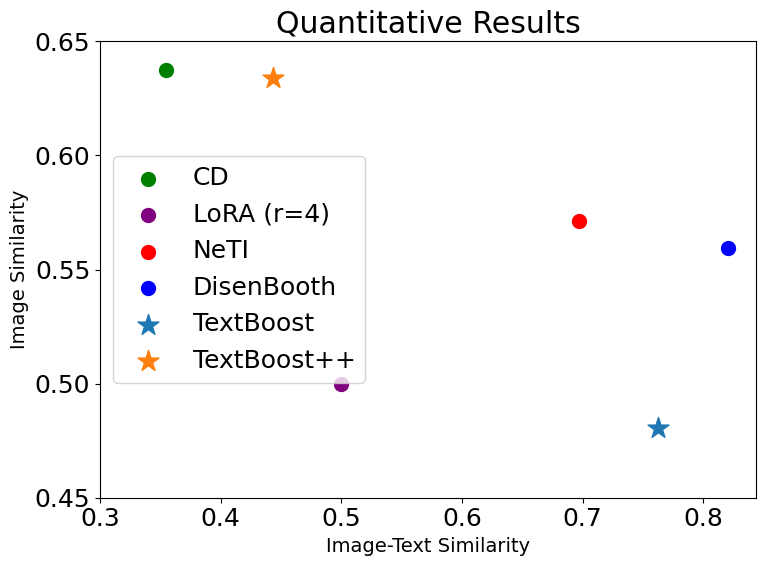

In [2]:
# (VQA, DINO)
data = {
    "CD": (0.35493776947259903, 0.6374574303627014),  # 250
    "LoRA (r=4)": (0.5, 0.5),  # 500
    "NeTI": (0.6970609, 0.5710884),  # 500
    "DisenBooth": (0.8203029, 0.5592447),  # 500
    "TextBoost": (0.7621528506278992, 0.4807492569088936),  # 100
    "TextBoost++": (0.44328485429286957, 0.6338975578546524),  # 100
}

plt.figure(figsize=(8, 6))

for i, (k, v) in enumerate(data.items()):
    # print(f"{k}: {v / 1e6:.2f}M")
    color = colors[k]
    marker = markers[k]
    if marker == "*":
        s = 250
    else:
        s = 100
    plt.scatter(*v, color=color, s=s, marker=markers[k], label=k)
    # plt.text(i, v / 1e6, f"{v / 1e6:.2f}M", ha="center", va="bottom")

plt.title("Quantitative Results")
plt.legend()
plt.yticks(np.arange(0.45, 0.66, 0.05))
plt.xticks(np.arange(0.3, 0.81, 0.1))
plt.xlabel("Image-Text Similarity", fontdict={"size": 14})
plt.ylabel("Image Similarity", fontdict={"size": 14})
plt.tight_layout()
plt.savefig("figures/quantitative.pdf")

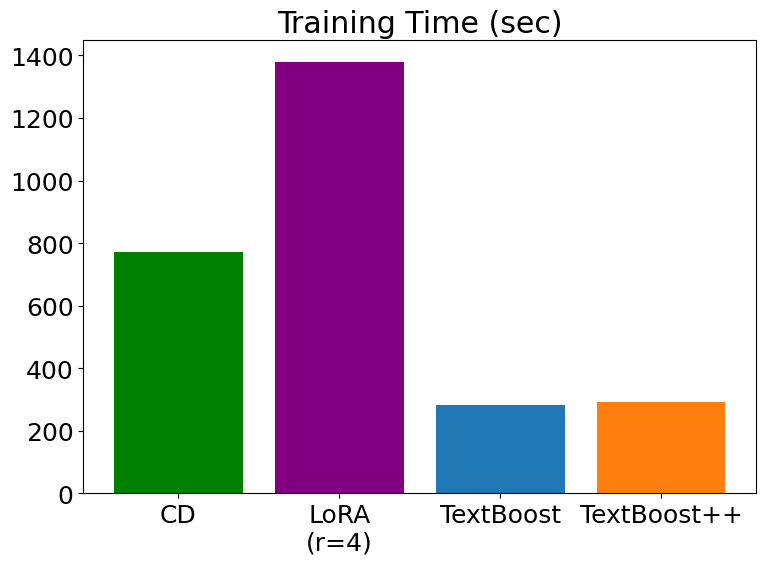

In [3]:
# Training time (sec).
data = {
    "CD": 772.47,  # 250
    "LoRA (r=4)": 1378.92,  # 500,  p.p.
    # "LoRA (r=4)": 298.14,  # 500, w/o p.p.
    "TextBoost": 281.59,  # 100
    "TextBoost++": 293.40,  # 100
    # "TextBoost++ (ur=2)": 445184,
}

plt.figure(figsize=(8, 6))

for i, (k, v) in enumerate(data.items()):
    # print(f"{k}: {v / 1e6:.2f}M")
    color = colors[k]
    key = k.replace(" ", "\n")
    plt.bar([key], [v], color=color, label=k)

plt.title("Training Time (sec)")
# plt.legend()
plt.tight_layout()
plt.savefig("figures/training_time.pdf", bbox_inches="tight")

<Figure size 800x600 with 0 Axes>

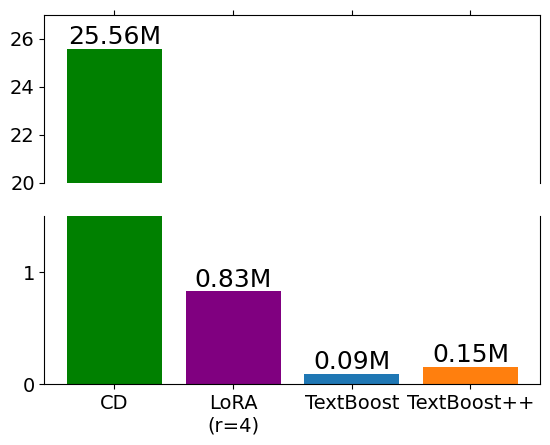

In [ ]:
# Number of parameters (M).
data = {
    "CD": 25559040,
    "LoRA (r=4)": 829952,
    "TextBoost": 94208,
    "TextBoost++": 151936,
    # "TextBoost++ (ur=2)": 445184,
}

plt.figure(figsize=(8, 6))

f, (ax, ax2) = plt.subplots(2, 1, sharex=True)

for i, (k, v) in enumerate(data.items()):
    # print(f"{k}: {v / 1e6:.2f}M")
    color = colors[k]
    key = k.replace(" ", "\n")
    ax.bar([key], [v / 1e6], color=color, label=k)

    ax2.bar([key], [v / 1e6], color=color, label=k)
    if k == "CD":
        ax.text(i, v / 1e6, f"{v / 1e6:.2f}M", ha="center", va="bottom")
    else:
        ax2.text(i, v / 1e6, f"{v / 1e6:.2f}M", ha="center", va="bottom")
    # ax2.text(i, v / 1e6, f"{v / 1e6:.2f}M", ha="center", va="bottom")

# plt.title("Number of Parameters (M)")
# plt.legend()
ax.set_ylim(20, 27)  # outliers only
ax2.set_ylim(0, 1.5)  # most of the data

ax.spines["bottom"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax.xaxis.tick_top()
ax.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

ax.tick_params(labelsize=14)
ax2.tick_params(labelsize=14)
ax2.set_yticks([0, 1])

# plt.tight_layout()
# plt.xticks([])
# plt.xlabel(" ")
# plt.tight_layout()
plt.savefig("figures/params.pdf")

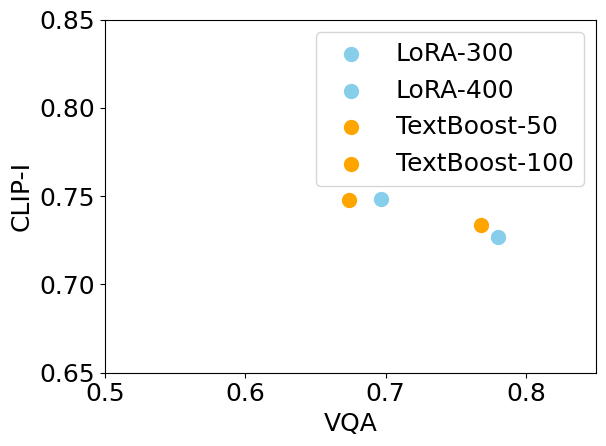

In [5]:
lora_200 = (0.78, 0.727)
lora_300 = (0.69675, 0.74825)
tb_50 = (0.768, 0.7335)
tb_100 = (0.674, 0.7477499999999999)

plt.scatter(*lora_200, color="skyblue", label="LoRA-300", s=100)
plt.scatter(*lora_300, color="skyblue", label="LoRA-400", s=100)
plt.scatter(*tb_50, color="orange", label="TextBoost-50", s=100)
plt.scatter(*tb_100, color="orange", label="TextBoost-100", s=100)
plt.xlabel("VQA")
plt.ylabel("CLIP-I")
plt.legend()
plt.xlim(0.5, 0.85)
plt.ylim(0.65, 0.85)
plt.tight_layout()

In [1]:
import csv
import numpy as np

# file, step = ("output/tb-sd21base-n1-kv/metric.csv", 100)
# file, step = ("output/tb-sd14-n1-ur1/metric.csv", 80)
# file, step = ("output/tb-sd15-n1-ur1/metric.csv", 80)
file, step = ("output/tb-sd21base-n1-kv_ur1/metric.csv", 80)

with open(file, "r") as f:
    reader = csv.reader(f)
    data = list(reader)

header = data[0]
vqa_idx = header.index("vqa")
dino_idx = header.index("dino_unseen")

vqa_scores = []
dino_scores = []
for row in data[1:]:
    if int(row[0]) == step:
        vqa_scores.append(float(row[vqa_idx]))
        dino_scores.append(float(row[dino_idx]))

print(f"VQA: {np.mean(vqa_scores):.3f}")
print(f"DINO: {np.mean(dino_scores):.3f}")

VQA: 0.559
DINO: 0.611


In [ ]:
import torch
from textboost.ti_utils import load_pipeline_from_checkpoint
from diffusers import DPMSolverMultistepScheduler

pipeline, identifier = load_pipeline_from_checkpoint(
    "stabilityai/stable-diffusion-xl-base-1.0",
    "output/tb_style-sdxlbase-ti/00",
)
scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.scheduler = scheduler
print(identifier)
print(pipeline.tokenizer)
print(pipeline.tokenizer_2)
# print(pipeline.unet)

SDXL: True


Expected types for text_encoder_2: ['CLIPTextModelWithProjection'], got TextModelWithProjection.
Expected types for text_encoder: ['CLIPTextModel'], got TextModel.
Keyword arguments {'safety_checker': None} are not expected by TextBoostSDXLPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 41.59it/s]


Loaded Adapter from checkpoint.
Loaded learned embeddings from checkpoint.
['<00_0> <00_1> <00_2>', '<00_0> <00_1> <00_2>']
['<00_0> <00_1> <00_2>', '<00_0> <00_1> <00_2>']
CLIPTokenizer(name_or_path='/local/kunkim/hf_home/hub/models--stabilityai--stable-diffusion-xl-base-1.0/snapshots/462165984030d82259a11f4367a4eed129e94a7b/tokenizer', vocab_size=49408, model_max_length=77, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49408: AddedToken("<00_0>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
	49409: AddedToken("<

['<00_0> <00_1> <00_2>', '<00_0> <00_1> <00_2>']
an elephant in <00_0> <00_1> <00_2>


100%|██████████| 25/25 [00:06<00:00,  3.80it/s]


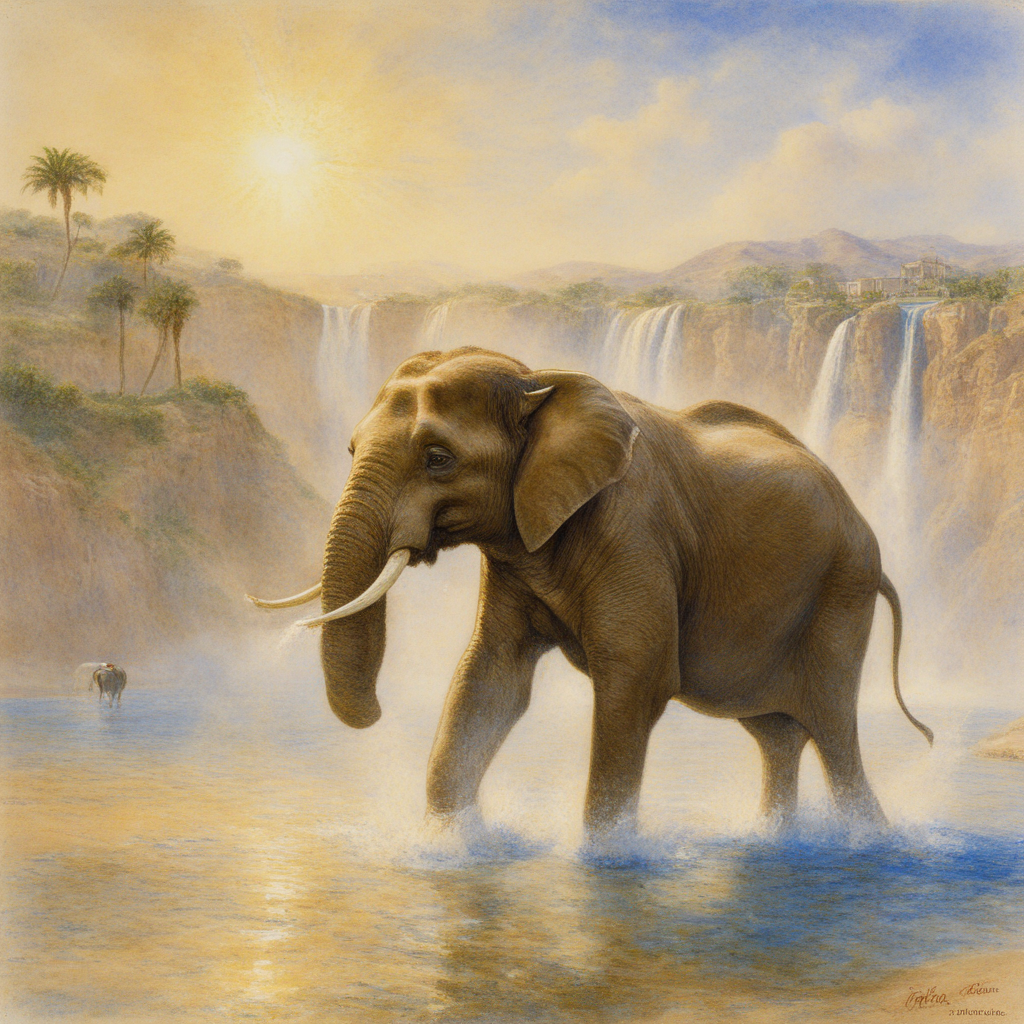

In [44]:
pipeline.to("cuda:1", dtype=torch.float16)
print(identifier)
prompt = f"an elephant in {identifier[0]}"
print(prompt)

generator = torch.Generator(device="cuda:1").manual_seed(1)
images = pipeline(
    prompt=prompt,
    num_inference_steps=25,
    generator=generator,
).images
images[0]

# 00: seed 1
# 01: seed 1

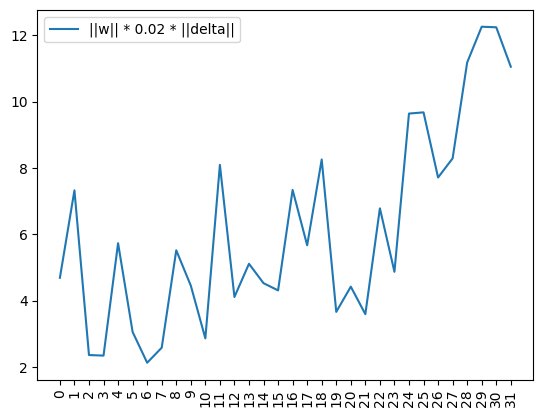

In [4]:
import matplotlib.pyplot as plt
import torch
from safetensors.torch import load_file
from transformers import CLIPTextModel, CLIPTextModelWithProjection

text_encoder = CLIPTextModelWithProjection.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", subfolder="text_encoder_2"
)

ckpt = load_file(
    "output/tb-sdxlbase-n1-adalr/backpack/checkpoint-1000/text_encoder_2/adapter_model.safetensors"
)
# for k, v in ckpt.items():
#     print(k)

fc2_norms = {}
fc2_lora_norms = {}
for k, v in text_encoder.named_parameters():
    if "fc2" in k and "bias" not in k:
        key = k.replace("text_model.encoder.layers.", "")
        key = key.replace(".mlp.fc2.weight", "")
        fc2_norms[key] = v.norm().item()

        lora_A = k.replace(".weight", ".lora_A.weight")
        lora_B = k.replace(".weight", ".lora_B.weight")
        try:
            w_A = ckpt[f"base_model.model.{lora_A}"]
            w_B = ckpt[f"base_model.model.{lora_B}"]
            W_delta = w_B @ w_A
            fc2_lora_norms[key] = W_delta.norm().item()
        except:
            fc2_lora_norms[key] = 0

delta = [fc2_lora_norms[k] / fc2_norms[k] for k in fc2_norms.keys()]

actual_norm = [fc2_norms[k] * 0.02 * fc2_lora_norms[k] for k in fc2_norms.keys()]

# plt.plot(fc2_norms.keys(), fc2_norms.values(), label="||w||")
# plt.plot(fc2_lora_norms.keys(), fc2_lora_norms.values(), label="delta")
# plt.plot(fc2_lora_norms.keys(), delta, label="delta")
plt.plot(fc2_lora_norms.keys(), actual_norm, label="||w|| * 0.02 * ||delta||")
plt.xticks(rotation=90)
plt.legend()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22')])

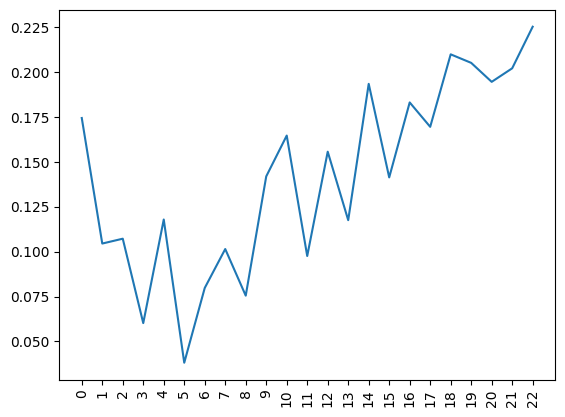

In [ ]:
text_encoder = CLIPTextModel.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base", subfolder="text_encoder"
)

ckpt = load_file(
    "output/tb-sd21base-n1-fc2-r1-ex/backpack/checkpoint-100/text_encoder/adapter_model.safetensors"
)

fc2_norms = {}
fc2_lora_norms = {}
for k, v in text_encoder.named_parameters():
    if "fc2" in k and "bias" not in k:
        key = k.replace("text_model.encoder.layers.", "")
        key = key.replace(".mlp.fc2.weight", "")
        fc2_norms[key] = v.norm().item()

        lora_A = k.replace(".weight", ".lora_A.weight")
        lora_B = k.replace(".weight", ".lora_B.weight")
        w_A = ckpt[f"base_model.model.{lora_A}"]
        w_B = ckpt[f"base_model.model.{lora_B}"]
        W_delta = w_B @ w_A
        fc2_lora_norms[key] = W_delta.norm().item()

delta = [fc2_lora_norms[k] / fc2_norms[k] for k in fc2_norms.keys()]

# plt.plot(fc2_norms.keys(), fc2_norms.values())
# plt.plot(fc2_lora_norms.keys(), fc2_lora_norms.values())
plt.plot(fc2_lora_norms.keys(), delta)
plt.xticks(rotation=90)

output/tb-sd21base-n1-q/metric.csv
100 - VQA:0.776, DINO:0.464
80 - VQA:0.789, DINO:0.458
60 - VQA:0.787, DINO:0.451
40 - VQA:0.798, DINO:0.444
20 - VQA:0.817, DINO:0.410
output/tb-sd21base-n1-k/metric.csv
100 - VQA:0.762, DINO:0.473
80 - VQA:0.769, DINO:0.465
60 - VQA:0.779, DINO:0.460
40 - VQA:0.794, DINO:0.447
20 - VQA:0.819, DINO:0.409
output/tb-sd21base-n1-v/metric.csv
100 - VQA:0.494, DINO:0.556
80 - VQA:0.549, DINO:0.535
60 - VQA:0.637, DINO:0.498
40 - VQA:0.745, DINO:0.455
20 - VQA:0.810, DINO:0.418
output/tb-sd21base-n1-o/metric.csv
100 - VQA:0.600, DINO:0.569
80 - VQA:0.640, DINO:0.552
60 - VQA:0.685, DINO:0.517
40 - VQA:0.760, DINO:0.490
20 - VQA:0.808, DINO:0.421
output/tb-sd21base-n1-fc1/metric.csv
100 - VQA:0.683, DINO:0.548
80 - VQA:0.694, DINO:0.543
60 - VQA:0.710, DINO:0.541
40 - VQA:0.740, DINO:0.508
20 - VQA:0.783, DINO:0.455
output/tb-sd21base-n1-fc2/metric.csv
100 - VQA:0.680, DINO:0.560
80 - VQA:0.701, DINO:0.544
60 - VQA:0.727, DINO:0.530
40 - VQA:0.759, DINO:0.5

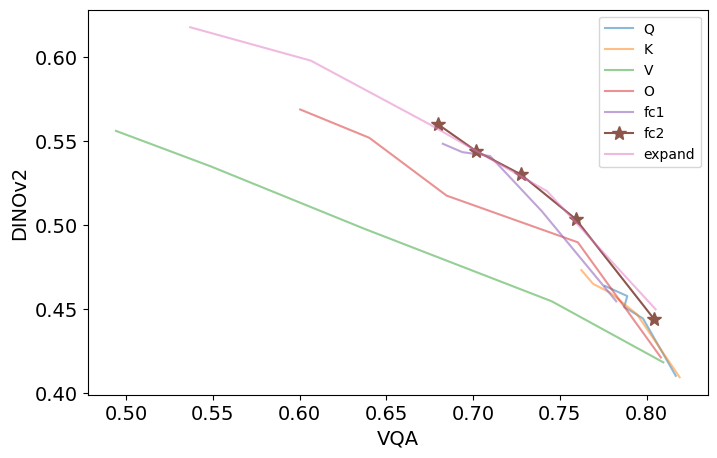

In [23]:
import csv
import os

import matplotlib.pyplot as plt
import numpy as np


def print_score(file):
    # with open("output/tb-sd21base-n1-test/metric.csv", "r") as f:
    with open(file, "r") as f:
        reader = csv.reader(f)
        data = list(reader)

    vqa = 0.0
    dino = 0.0
    n = 0
    vqa = {}
    dino = {}
    for d in data[1:]:
        i = int(d[0])
        if i not in vqa:
            vqa[i] = []
            dino[i] = []
        vqa[i].append(float(d[3]))
        dino[i].append(float(d[7]))

    for i in vqa.keys():
        vqa[i] = np.mean(np.asarray(vqa[i]))
        dino[i] = np.mean(np.asarray(dino[i]))

    label = os.path.dirname(file).split("/")[-1].split("-")[-1]
    marker = None
    alpha = 0.5
    if label in "qkvo":
        label = label.upper()
        marker = None
    elif label == "fc1":
        marker = None
        alpha = 0.6
    elif label == "fc2":
        marker = "*"
        alpha = 1.0

    plt.plot(
        list(vqa.values()),
        list(dino.values()),
        alpha=alpha,
        marker=marker,
        markersize=10,
        label=label,
    )
    return vqa, dino


files = [
    "output/tb-sd21base-n1-q/metric.csv",
    "output/tb-sd21base-n1-k/metric.csv",
    "output/tb-sd21base-n1-v/metric.csv",
    "output/tb-sd21base-n1-o/metric.csv",
    "output/tb-sd21base-n1-fc1/metric.csv",
    "output/tb-sd21base-n1-fc2/metric.csv",
    # "output/tb-sd21base-n1-exclude_last/metric.csv",
    "output/tb-sd21base-n1-expand/metric.csv",
]
plt.figure(figsize=(8, 5))
for file in files:
    print(file)
    vqa, dino = print_score(file)
    for k in vqa:
        print(f"{k} - VQA:{vqa[k]:.3f}, DINO:{dino[k]:.3f}")

plt.xlabel("VQA", fontdict={"size": 14})
plt.ylabel("DINOv2", fontdict={"size": 14})
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.savefig("adapter_abal.pdf")

In [24]:
print(f"{145_408 / 1_000_000:.2f}M")

0.15M
